# Generic Transformer Imputer for Mixed Data Types

This notebook implements a Transformer-based imputer that can handle both numerical and categorical features in a dataset. It automatically detects column types, applies appropriate preprocessing, and uses a modified Transformer architecture to impute missing values.

Jurnal Referensi Utama : I. Kowsar, S.B Rabbani, M.D Samad
“Attention-Based Imputation of Missing Values in Electronic Health Records Tabular Data,”
in  Proc (IEEE Int Conf Healthc Inform). 2024 June ; 2024: 177–182. doi:10.1109/ichi61247.2024.00030.

Link PDF Jurnal : https://pmc.ncbi.nlm.nih.gov/articles/PMC11463999/pdf/nihms-2010820.pdf


Kelompok 2 Missing Value
```
Muhammad Zahran Albara,122140240
Revolusi A-Ghifari,123140199
Casey Z.D Manurung ,122140054
Royfran Roger Valentino,122140239
Pricelia Putri,122140075
Hayyatul Fajri,122140103
```


In [12]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, accuracy_score
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
import warnings

warnings.filterwarnings('ignore', category=UserWarning)

### 1. Load and Prepare Data

In [13]:
df_raw = pd.read_csv('2021.csv', nrows=10000)

df_clean = df_raw.drop(columns=['TANGGAL', 'NO_TRANSAKSI'])

numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Detected {len(numeric_cols)} numeric columns: {numeric_cols}")
print(f"Detected {len(categorical_cols)} categorical columns: {categorical_cols}")

Detected 4 numeric columns: ['QTY_MSK', 'NILAI_MSK', 'QTY_KLR', 'NILAI_KLR']
Detected 3 categorical columns: ['KODE', 'NAMA_PRODUK', 'UNIT']


### 2. Create Artificial Missing Data
First, we'll create a copy of the clean data and artificially introduce NaN values. This will be our testbed.

In [14]:
rng = np.random.RandomState(42)
missing_fraction = 0.20 # Increased missing fraction for a clearer comparison
mask_matrix = rng.rand(*df_clean.shape) < missing_fraction
df_with_missing = df_clean.mask(mask_matrix)

missing_mask = df_with_missing.isna()

print("Missing Values Introduced per Column:")
print(missing_mask.sum())

Missing Values Introduced per Column:
KODE           2028
NAMA_PRODUK    1946
UNIT           1939
QTY_MSK        2053
NILAI_MSK      2009
QTY_KLR        2020
NILAI_KLR      1972
dtype: int64


### 3. Imputation Method 1: Mean/Mode Imputation (Baseline)

In [15]:
df_mean_imputed = df_with_missing.copy()

# Impute numeric columns with mean
num_imputer = SimpleImputer(strategy='mean')
df_mean_imputed[numeric_cols] = num_imputer.fit_transform(df_mean_imputed[numeric_cols])

# Impute categorical columns with mode (most frequent)
cat_imputer = SimpleImputer(strategy='most_frequent')
df_mean_imputed[categorical_cols] = cat_imputer.fit_transform(df_mean_imputed[categorical_cols])

print("Data after Mean/Mode Imputation (first 5 rows):")
df_mean_imputed.head()

Data after Mean/Mode Imputation (first 5 rows):


,KODE,NAMA_PRODUK,UNIT,QTY_MSK,NILAI_MSK,QTY_KLR,NILAI_KLR
0,A000001,ANATON TAB,STRIP,10.000000,7757.455698,0.0,0.0
1,A000001,ANATON TAB,STRIP,3.875551,3000.000000,0.0,0.0
2,A00021,AMOXICILIN 500MG,STRIP,1.000000,3000.000000,0.0,0.0
3,A00021,ANATON TAB,STRIP,1.000000,3000.000000,0.0,0.0
4,A000001,AMOXICILIN 500MG,STRIP,3.875551,7757.455698,0.0,0.0


### 4. Imputation Method 2: Transformer Model
Now we'll preprocess the data and train the Transformer to impute the same missing values.

In [16]:
df_processed = df_clean.copy()
cat_encoders = {}
cat_cardinalities = []
all_cols = list(df_clean.columns)
numeric_col_indices = [all_cols.index(col) for col in numeric_cols]
categorical_col_indices = [all_cols.index(col) for col in categorical_cols]

for col in categorical_cols:
    df_processed[col] = df_processed[col].astype(str).fillna('__MISSING__')
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col])
    cat_encoders[col] = le
    cardinality = len(le.classes_)
    cat_cardinalities.append(cardinality)

for col in numeric_cols:
    df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')

numeric_scaler = StandardScaler()
df_processed[numeric_cols] = numeric_scaler.fit_transform(df_processed[numeric_cols])
df_processed = df_processed.fillna(0)

# Create observed tensor with missing values for the model
df_observed_scaled = df_processed.mask(missing_mask).fillna(0)

X_obs_t = torch.tensor(df_observed_scaled.values, dtype=torch.float32)
mask_t = torch.tensor(~missing_mask.values, dtype=torch.float32)
X_full_t = torch.tensor(df_processed.values, dtype=torch.float32)

batch_size = 64
dataset = TensorDataset(X_obs_t, mask_t, X_full_t)
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [17]:
class GenericTabTransformer(nn.Module):
    def __init__(self, num_features, cat_indices, cat_cardinalities, d_model=64, nhead=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.num_features = num_features
        self.d_model = d_model
        self.cat_indices = cat_indices
        self.num_indices = [i for i in range(num_features) if i not in cat_indices]

        self.cat_embedders = nn.ModuleList([nn.Embedding(card, d_model) for card in cat_cardinalities])
        self.num_embedder = nn.Linear(1, d_model)
        self.feature_embedder = nn.Embedding(num_features, d_model)

        encoder_layer = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward=d_model*4, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.num_out = nn.Linear(d_model, 1)
        self.cat_out = nn.ModuleList([nn.Linear(d_model, card) for card in cat_cardinalities])

    def forward(self, x, mask):
        b, f = x.size()
        embeddings = []
        cat_idx_map = {orig_idx: new_idx for new_idx, orig_idx in enumerate(self.cat_indices)}

        for i in range(f):
            feat_emb = self.feature_embedder(torch.tensor([i], device=x.device)).expand(b, -1)
            if i in self.cat_indices:
                val_emb = self.cat_embedders[cat_idx_map[i]](x[:, i].long())
            else:
                val_emb = self.num_embedder(x[:, i].unsqueeze(-1))
            embeddings.append(val_emb + feat_emb)

        tokens = torch.stack(embeddings, dim=1)
        out = self.transformer(tokens)
        
        num_preds = self.num_out(out[:, self.num_indices, :]).squeeze(-1)
        cat_preds = []
        for i, orig_idx in enumerate(self.cat_indices):
            cat_preds.append(self.cat_out[i](out[:, orig_idx, :]))
        return num_preds, cat_preds

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GenericTabTransformer(
    num_features=len(all_cols),
    cat_indices=categorical_col_indices,
    cat_cardinalities=cat_cardinalities,
    d_model=64, nhead=4, num_layers=2
).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
mse_loss_fn = nn.MSELoss()
ce_loss_fn = nn.CrossEntropyLoss()

In [19]:
def calculate_loss(num_preds, cat_preds, yb, maskb, model):
    yb_num = yb[:, model.num_indices]
    maskb_num = maskb[:, model.num_indices]
    
    num_missing_mask = (1 - maskb_num)
    num_loss = mse_loss_fn(num_preds * num_missing_mask, yb_num * num_missing_mask)

    cat_loss = 0.0
    for i, orig_idx in enumerate(model.cat_indices):
        yb_cat = yb[:, orig_idx].long()
        maskb_cat = maskb[:, orig_idx]
        cat_missing_mask = (1 - maskb_cat)
        if cat_missing_mask.sum() > 0:
            loss = ce_loss_fn(cat_preds[i][cat_missing_mask==1], yb_cat[cat_missing_mask==1])
            cat_loss += loss
    return num_loss + cat_loss

epochs = 50
for epoch in range(1, epochs + 1):
    model.train()
    for xb, maskb, yb in train_loader:
        xb, maskb, yb = xb.to(device), maskb.to(device), yb.to(device)
        optimizer.zero_grad()
        num_preds, cat_preds = model(xb, maskb)
        loss = calculate_loss(num_preds, cat_preds, yb, maskb, model)
        if torch.isfinite(loss):
            loss.backward()
            optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Avg Train Loss: {loss.item():.4f}")

Epoch 010 | Avg Train Loss: 0.1093
Epoch 020 | Avg Train Loss: 0.1344
Epoch 030 | Avg Train Loss: 0.1107
Epoch 040 | Avg Train Loss: 0.0753
Epoch 050 | Avg Train Loss: 2.1104


In [20]:
model.eval()
with torch.no_grad():
    num_imputed_scaled, cat_imputed_logits = model(X_obs_t.to(device), mask_t.to(device))

df_transformer_imputed = df_with_missing.copy()

num_imputed_unscaled = numeric_scaler.inverse_transform(num_imputed_scaled.cpu())
df_transformer_imputed[numeric_cols] = num_imputed_unscaled

for i, col in enumerate(categorical_cols):
    imputed_labels = torch.argmax(cat_imputed_logits[i], dim=1).cpu().numpy()
    df_transformer_imputed[col] = cat_encoders[col].inverse_transform(imputed_labels)

df_transformer_final = df_with_missing.fillna(df_transformer_imputed)

print("Data after Transformer Imputation (first 5 rows):")
df_transformer_final.head()

Data after Transformer Imputation (first 5 rows):


,KODE,NAMA_PRODUK,UNIT,QTY_MSK,NILAI_MSK,QTY_KLR,NILAI_KLR
0,A000001,ANATON TAB,STRIP,10.000000,4168.986510,-0.045933,-0.071057
1,A000001,ANATON TAB,STRIP,10.545261,3000.000000,0.000000,0.000000
2,A00015,ALLOPURINOL 100MG,STRIP,1.000000,3000.000000,0.000000,0.000000
3,A000001,ANATON TAB,STRIP,1.000000,3000.000000,0.005473,0.000000
4,A000001,AMLODIPINE 5MG,STRIP,2.759261,7625.930486,0.000000,0.000000


### 5. Accuracy and Comparison

In [21]:
results = {}
for col in numeric_cols:
    missing_indices = missing_mask[col]
    original_vals = df_clean[col][missing_indices]
    mean_imputed_vals = df_mean_imputed[col][missing_indices]
    transformer_imputed_vals = df_transformer_final[col][missing_indices]
    
    rmse_mean = np.sqrt(mean_squared_error(original_vals, mean_imputed_vals))
    rmse_transformer = np.sqrt(mean_squared_error(original_vals, transformer_imputed_vals))
    results[col] = {'RMSE_Mean': rmse_mean, 'RMSE_Transformer': rmse_transformer}

for col in categorical_cols:
    missing_indices = missing_mask[col]
    original_vals = df_clean[col][missing_indices]
    mode_imputed_vals = df_mean_imputed[col][missing_indices]
    transformer_imputed_vals = df_transformer_final[col][missing_indices]
    
    acc_mode = accuracy_score(original_vals, mode_imputed_vals)
    acc_transformer = accuracy_score(original_vals, transformer_imputed_vals)
    results[col] = {'Accuracy_Mode': acc_mode, 'Accuracy_Transformer': acc_transformer}

results_df = pd.DataFrame(results).T
print("Comparison of Imputation Accuracy (on missing values only):")
results_df

Comparison of Imputation Accuracy (on missing values only):


,RMSE_Mean,RMSE_Transformer,Accuracy_Mode,Accuracy_Transformer
QTY_MSK,12.517530,10.969778,NaN,NaN
NILAI_MSK,7850.418059,2041.499722,NaN,NaN
QTY_KLR,0.000000,0.082270,NaN,NaN
NILAI_KLR,0.000000,0.056803,NaN,NaN
KODE,NaN,NaN,0.142505,0.934911
NAMA_PRODUK,NaN,NaN,0.153649,0.932169
UNIT,NaN,NaN,0.726147,0.992780


### 6. Visualization Comparison

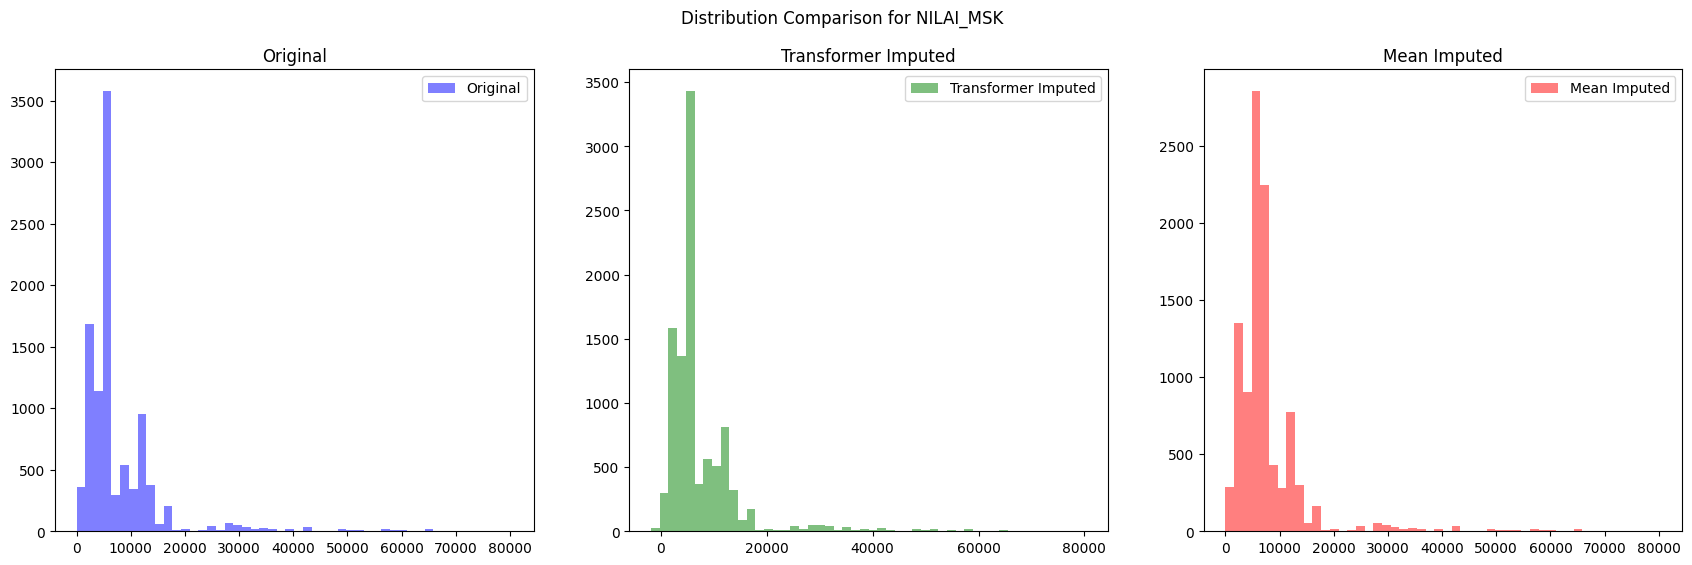

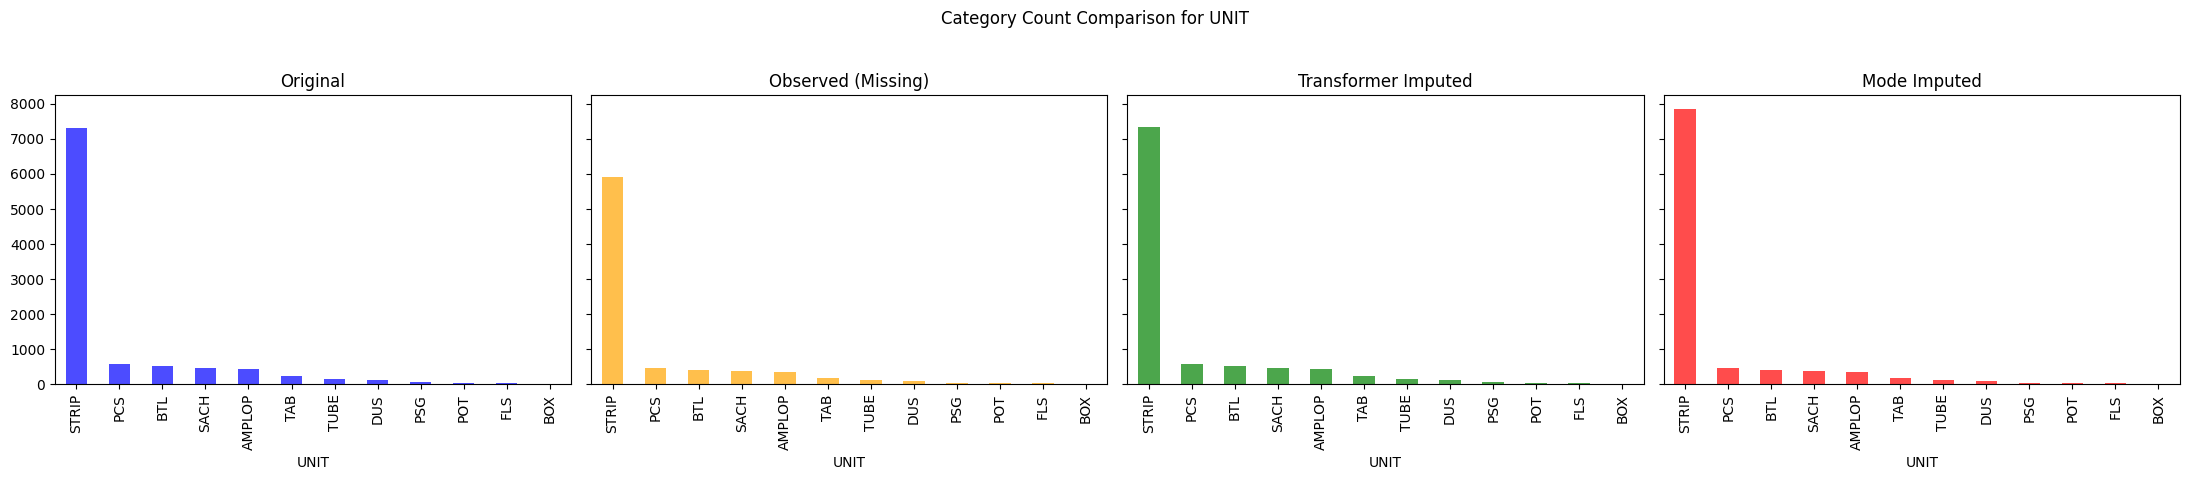

In [23]:
num_col_to_plot = 'NILAI_MSK'


fig, axes = plt.subplots(1, 3, figsize=(21, 6))
axes[0].hist(df_clean[num_col_to_plot].dropna(), bins=50, color='blue', alpha=0.5, label='Original')
axes[0].set_title('Original')
axes[0].legend()
axes[1].hist(df_transformer_final[num_col_to_plot], bins=50, color='green', alpha=0.5, label='Transformer Imputed')
axes[1].set_title('Transformer Imputed')
axes[1].legend()
axes[2].hist(df_mean_imputed[num_col_to_plot], bins=50, color='red', alpha=0.5, label='Mean Imputed')
axes[2].set_title('Mean Imputed')
axes[2].legend()
fig.suptitle(f'Distribution Comparison for {num_col_to_plot}')
plt.show()

cat_col_to_plot = 'UNIT'

fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
df_clean[cat_col_to_plot].value_counts().plot(kind='bar', ax=axes[0], color='blue', alpha=0.7, title='Original')
df_with_missing[cat_col_to_plot].value_counts().plot(kind='bar', ax=axes[1], color='orange', alpha=0.7, title='Observed (Missing)')
df_transformer_final[cat_col_to_plot].value_counts().plot(kind='bar', ax=axes[2], color='green', alpha=0.7, title='Transformer Imputed')
df_mean_imputed[cat_col_to_plot].value_counts().plot(kind='bar', ax=axes[3], color='red', alpha=0.7, title='Mode Imputed')
fig.suptitle(f'Category Count Comparison for {cat_col_to_plot}')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()